<a href="https://colab.research.google.com/github/norasaleh1/Data-Science-Project/blob/main/Notebooks/Phase-2/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install arabic-reshaper python-bidi
import arabic_reshaper
from bidi.algorithm import get_display
import numpy as np
import re


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 10.4 MB/s eta 0:00:00


# BOE + Istitlaa


Load Primary Datasets (BOE + Istitlaa)

In [ ]:


boe = pd.read_csv("boe_cleaned.csv", encoding="utf-8-sig")
istitlaa = pd.read_csv("istitlaa_cleaned.csv", encoding="utf-8-sig")


print("🔹 BOE Dataset:")
display(boe.head())

print("\n🔹 Istitlaa Dataset:")
display(istitlaa.head())


🔹 BOE Dataset:


,Section,Chapter,Article,Text,Status,Source
0,الباب الأول التعريفات والأحكام العامة,الفصل الأول التعريفات,المادة الأولى,يسمى هذا النظام نظام العمل.,عادية,https//laws.boe.gov.sa/boelaws/laws/lawdetails...
1,الباب الأول التعريفات والأحكام العامة,الفصل الأول التعريفات,المادة الثانية,- تعديل تعريف العامل وذلك بموجب المرسوم الملكي...,معدلة,https//laws.boe.gov.sa/boelaws/laws/lawdetails...
2,الباب الأول التعريفات والأحكام العامة,الفصل الأول التعريفات,المادة الثالثة,عُدلت هذه المادة بموجب المرسوم الملكي رقم (م /...,معدلة,https//laws.boe.gov.sa/boelaws/laws/lawdetails...
3,الباب الأول التعريفات والأحكام العامة,الفصل الأول التعريفات,المادة الرابعة,يجب على صاحب العمل والعامل عند تطبيق أحكام هذا...,عادية,https//laws.boe.gov.sa/boelaws/laws/lawdetails...
4,الباب الأول التعريفات والأحكام العامة,الفصل الأول التعريفات,المادة الخامسة,تم تعديل هذه المادة بموجب المرسوم الملكي رقم (...,معدلة,https//laws.boe.gov.sa/boelaws/laws/lawdetails...



🔹 Istitlaa Dataset:


,Article,Current Text,Proposed Text,URL
0,المادة 2,المادة (2) في تنفيذ أحكام الفقرة الفرعية (د) م...,حذف المادة ​,https//istitlaa.ncc.gov.sa/ar/labor/hrsd/regul...
1,المادة 7,المادة (7) في تنفيذ أحكام المواد (الثانية والع...,المادة (7) في تنفيذ أحكام المواد (الثانية والع...,https//istitlaa.ncc.gov.sa/ar/labor/hrsd/regul...
2,المادة 10,المادة (10) في تنفيذ أحكام (المادة الثلاثون) م...,المادة (10) في تنفيذ أحكام (المادة الثلاثون) م...,https//istitlaa.ncc.gov.sa/ar/labor/hrsd/regul...
3,المادة 13,المادة (13) في تنفيذ أحكام (المادة التاسعة وال...,المادة (13) في تنفيذ أحكام (المادة التاسعة وال...,https//istitlaa.ncc.gov.sa/ar/labor/hrsd/regul...
4,المادة 15,المادة (15) في تنفيذ أحكام (المادة الثانية وال...,المادة (15) في تنفيذ أحكام (المادة الثانية وال...,https//istitlaa.ncc.gov.sa/ar/labor/hrsd/regul...


 Overview of  BOE Dataset


In [ ]:
print("🔹 BOE Dataset Info:")
boe.info()

print("\n🔹 Istitlaa Dataset Info:")
istitlaa.info()


🔹 BOE Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 248 entries, 0 to 247
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Section  248 non-null    object
 1   Chapter  248 non-null    object
 2   Article  248 non-null    object
 3   Text     248 non-null    object
 4   Status   248 non-null    object
 5   Source   248 non-null    object
dtypes: object(6)
memory usage: 11.8+ KB

🔹 Istitlaa Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Article        16 non-null     object
 1   Current Text   16 non-null     object
 2   Proposed Text  16 non-null     object
 3   URL            16 non-null     object
dtypes: object(4)
memory usage: 644.0+ bytes


Status Distribution in BOE


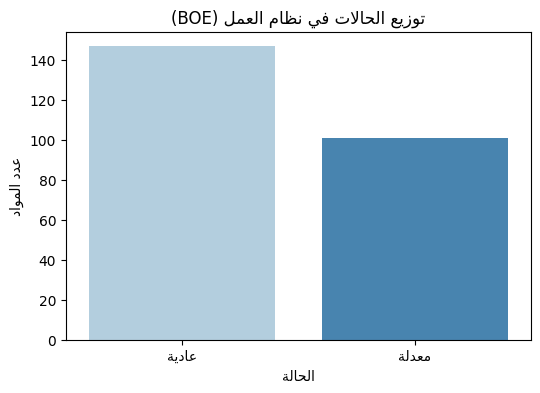

In [ ]:


def fix_arabic(text):
    return get_display(arabic_reshaper.reshape(text))


boe['Status_fixed'] = boe['Status'].apply(fix_arabic)


status_counts = boe['Status_fixed'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=status_counts.index, y=status_counts.values, palette="Blues")
plt.title(fix_arabic("توزيع الحالات في نظام العمل (BOE)"))
plt.xlabel(fix_arabic("الحالة"))
plt.ylabel(fix_arabic("عدد المواد"))
plt.show()



The plot displays the count of article statuses in the BOE dataset, showing that regular (عادية) articles are more frequent than amended (معدلة) ones

 the most frequent sections in the BOE Labor Law.

🔹 Number of Articles per Section:
Section
الباب الخامس علاقات العمل                                                                                            39
الباب السادس شروط العمل وظروفه                                                                                       30
الباب الثامن الوقاية من مخاطر العمل والوقاية من الحوادث الصناعية الكبرى وإصابات العمل والخدمات الصحية والاجتماعية    28
الباب الأول التعريفات والأحكام العامة                                                                                21
الباب الرابع عشر هيئات تسوية الخلافات العمالية                                                                       19
الباب الحادي عشر عقد العمل البحري                                                                                    17
الباب الخامس عشر العقوبات                                                                                            17
الباب الثالث عشر تفتيش العمل                                                                                         1

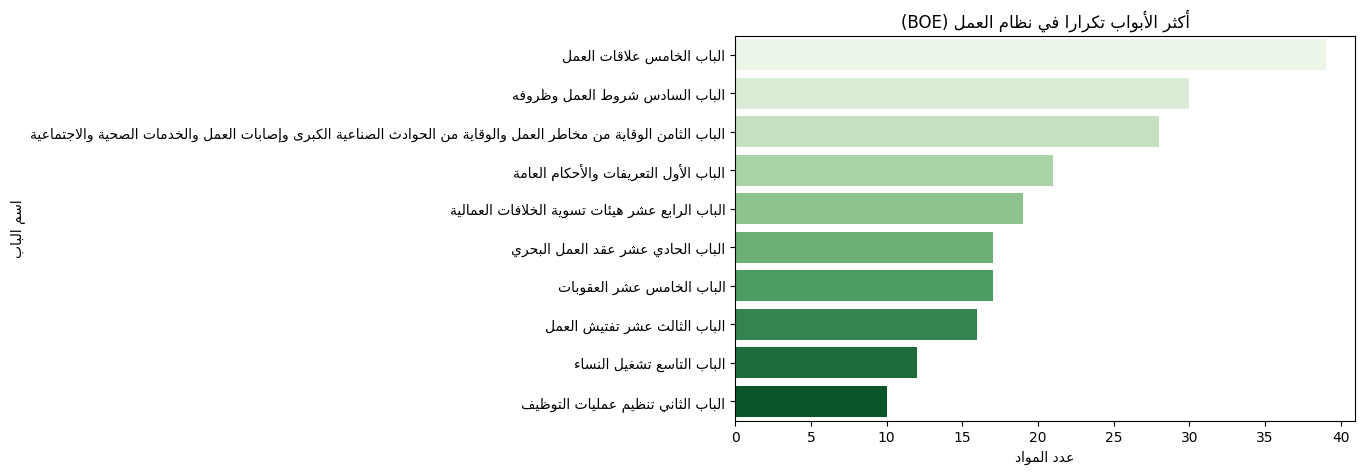

In [ ]:
section_counts = boe['Section'].value_counts()

print("🔹 Number of Articles per Section:")
print(section_counts.head(10))


boe['Section_fixed'] = boe['Section'].apply(fix_arabic)
section_counts_fixed = boe['Section_fixed'].value_counts().head(10)


plt.figure(figsize=(8,5))
sns.barplot(y=section_counts_fixed.index, x=section_counts_fixed.values, palette="Greens")
plt.title(fix_arabic("أكثر الأبواب تكرارًا في نظام العمل (BOE)"))
plt.xlabel(fix_arabic("عدد المواد"))
plt.ylabel(fix_arabic("اسم الباب"))
plt.show()



الباب الخامس (علاقات العمل) contains the largest number of articles, followed by الباب السادس (شروط العمل وظروفه) and الباب الثامن (الوقاية من مخاطر العمل), indicating that these areas are the most elaborated within the labor law.


Relationship Between Section and Article Status (BOE)

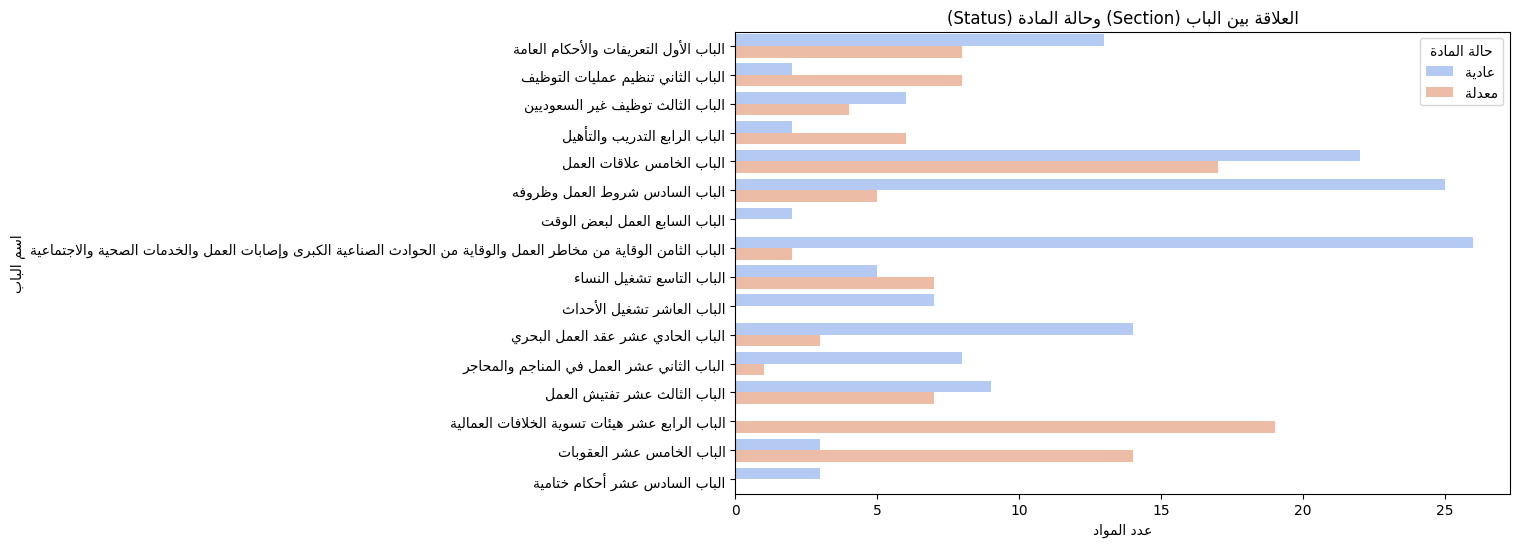

In [ ]:

boe['Status_fixed'] = boe['Status'].apply(fix_arabic)
boe['Section_fixed'] = boe['Section'].apply(fix_arabic)

plt.figure(figsize=(10,6))
sns.countplot(data=boe, y='Section_fixed', hue='Status_fixed', palette='coolwarm')

plt.title(fix_arabic("العلاقة بين الباب (Section) وحالة المادة (Status)"))
plt.xlabel(fix_arabic("عدد المواد"))
plt.ylabel(fix_arabic("اسم الباب"))
plt.legend(title=fix_arabic("حالة المادة"))
plt.show()


The chart compares article statuses (عادية vs معدّلة) across different sections of the BOE Labor Law.
It shows that most sections contain a higher number of regular articles, though some — such as الباب الرابع عشر and الباب الخامس عشر — include a larger portion of amended articles.


# EDA Summary

The BOE dataset includes the full text of the Saudi Labor Law.
Analysis focused on the number of articles per section, legal status (active, amended, repealed),
and correlations between section and status using bar charts and counts.


# Metadata Review

The dataset was obtained from *BOE.gov.sa*, the official Saudi Bureau of Experts platform.
It represents the legally binding version of the Saudi Labor Law as issued by the Council of Ministers.


# Bias Awareness

As an official legal text, the dataset is unbiased.
However, differences may appear when compared to simplified or user-generated sources.



# Istitlaa



Overview of Istitlaa Dataset

In [ ]:

display(istitlaa.head())


print("Shape:", istitlaa.shape)


istitlaa.info()


,Article,Current Text,Proposed Text,URL
0,المادة 2,المادة (2) في تنفيذ أحكام الفقرة الفرعية (د) م...,حذف المادة ​,https//istitlaa.ncc.gov.sa/ar/labor/hrsd/regul...
1,المادة 7,المادة (7) في تنفيذ أحكام المواد (الثانية والع...,المادة (7) في تنفيذ أحكام المواد (الثانية والع...,https//istitlaa.ncc.gov.sa/ar/labor/hrsd/regul...
2,المادة 10,المادة (10) في تنفيذ أحكام (المادة الثلاثون) م...,المادة (10) في تنفيذ أحكام (المادة الثلاثون) م...,https//istitlaa.ncc.gov.sa/ar/labor/hrsd/regul...
3,المادة 13,المادة (13) في تنفيذ أحكام (المادة التاسعة وال...,المادة (13) في تنفيذ أحكام (المادة التاسعة وال...,https//istitlaa.ncc.gov.sa/ar/labor/hrsd/regul...
4,المادة 15,المادة (15) في تنفيذ أحكام (المادة الثانية وال...,المادة (15) في تنفيذ أحكام (المادة الثانية وال...,https//istitlaa.ncc.gov.sa/ar/labor/hrsd/regul...


Shape: (16, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Article        16 non-null     object
 1   Current Text   16 non-null     object
 2   Proposed Text  16 non-null     object
 3   URL            16 non-null     object
dtypes: object(4)
memory usage: 644.0+ bytes


Article Proposal Frequency in Istitlaa

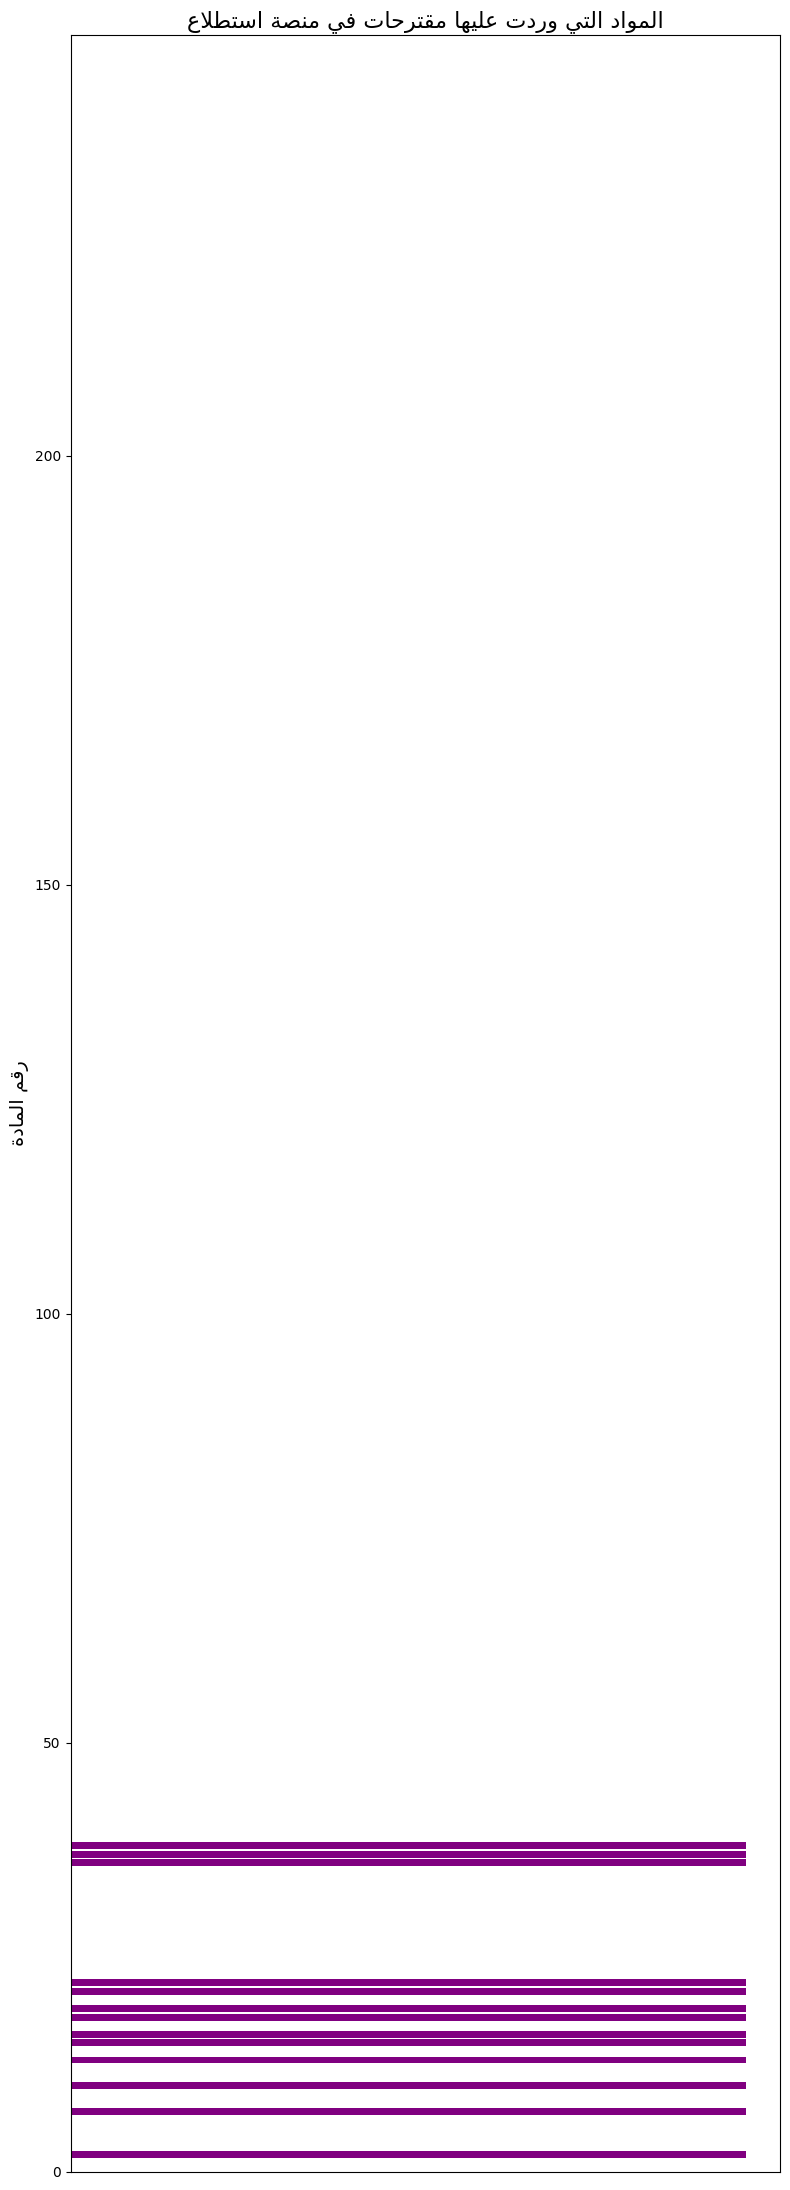

عدد المواد التي وردت عليها مقترحات: 13
المواد هي:

المادة رقم: 2
المادة رقم: 7
المادة رقم: 10
المادة رقم: 13
المادة رقم: 15
المادة رقم: 16
المادة رقم: 18
المادة رقم: 19
المادة رقم: 21
المادة رقم: 22
المادة رقم: 36
المادة رقم: 37
المادة رقم: 38


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display
import re

# -----------------------------
# 1) إصلاح العربية
# -----------------------------
def fix_arabic(text):
    return get_display(arabic_reshaper.reshape(str(text)))


def get_article_num(text):
    if not isinstance(text, str):
        return None


    num = re.search(r'\d+', text)
    if num:
        return int(num.group())


    words = {
        "الثانية": 2, "الثالثة": 3, "الرابعة": 4, "الخامسة": 5,
        "السادسة": 6, "السابعة": 7, "الثامنة": 8, "التاسعة": 9,
        "العاشرة": 10, "الحادية عشرة": 11, "الثانية عشرة": 12,
        "الثالثة عشرة": 13, "الرابعة عشرة": 14, "الخامسة عشرة": 15,
        "السادسة عشرة": 16, "السابعة عشرة": 17, "الثامنة عشرة": 18,
        "التاسعة عشرة": 19, "العشرون": 20
    }

    for w, n in words.items():
        if w in text:
            return n

    return None


istitlaa["Article_num"] = istitlaa["Article"].apply(get_article_num)


istitlaa_articles = sorted(
    istitlaa['Article_num'].dropna().astype(int).unique()
)


total_articles = 248

plt.figure(figsize=(8, 22))

for art in istitlaa_articles:
    plt.barh(
        y=art,
        width=1,
        color="purple"
    )

plt.ylim(0, total_articles + 1)

plt.title(
    fix_arabic("المواد التي وردت عليها مقترحات في منصة استطلاع"),
    fontsize=16
)
plt.ylabel(fix_arabic("رقم المادة"), fontsize=14)
plt.xlabel("")
plt.xticks([])

plt.tight_layout()
plt.show()


print("عدد المواد التي وردت عليها مقترحات:", len(istitlaa_articles))
print("المواد هي:\n")

for art in istitlaa_articles:
    print("المادة رقم:", art)


Categorize Proposed Changes in Istitlaa

In [ ]:


def classify_change(row):
    current = str(row['Current Text']).strip()
    proposed = str(row['Proposed Text']).strip()

    if "حذف" in proposed or proposed == "" or proposed == "N/A":
        return "حذف المادة"
    elif current == proposed:
        return "بدون تعديل"
    else:
        return "تعديل أو استبدال النص"

istitlaa['Change_Type'] = istitlaa.apply(classify_change, axis=1)


istitlaa[['Article', 'Change_Type']].head()


,Article,Change_Type
0,المادة 2,حذف المادة
1,المادة 7,تعديل أو استبدال النص
2,المادة 10,تعديل أو استبدال النص
3,المادة 13,تعديل أو استبدال النص
4,المادة 15,تعديل أو استبدال النص


Distribution of Change Types in Istitlaa

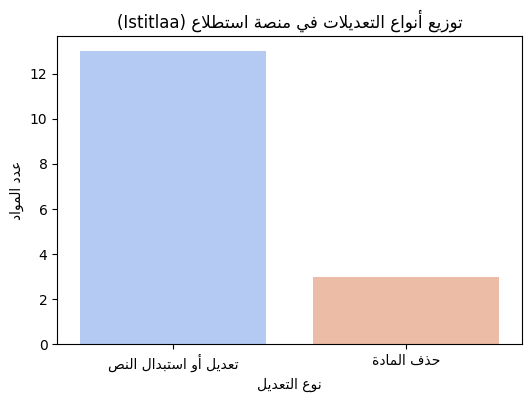

In [ ]:

change_counts = istitlaa['Change_Type'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=change_counts.index.map(fix_arabic), y=change_counts.values, palette="coolwarm")
plt.title(fix_arabic("توزيع أنواع التعديلات في منصة استطلاع (Istitlaa)"))
plt.xlabel(fix_arabic("نوع التعديل"))
plt.ylabel(fix_arabic("عدد المواد"))
plt.show()




The chart shows the breakdown of proposed amendments in the Istitlaa dataset.
Most proposals involve editing or replacing existing text, while a smaller portion suggests deleting entire articles.

# EDA Summary

The Istitlaa dataset includes public feedback on proposed amendments to the labor law.
The analysis categorized proposal types (addition, deletion, modification),
counted suggestions per article, and compared overlapping article numbers with BOE data.


# Metadata Review

Collected from *Istitlaa.sa*, the official Saudi public consultation platform.
The data represents proposals submitted by individuals and organizations.


# Bias Awareness

The data reflects individual opinions and suggestions,
so it may not represent legal or expert consensus.



Compare Between BOE and Istitlaa

In [ ]:


boe_stats = {
    "Dataset": "BOE (Official Law)",
    "Rows": len(boe),
    "Avg_Text_Length": round(boe["Text"].astype(str).apply(len).mean(), 2),
    "Median_Text_Length": round(boe["Text"].astype(str).apply(len).median(), 2),
    "Unique_Articles": boe["Article"].nunique()
}

istitlaa_stats = {
    "Dataset": "Istitlaa (Public Consultation)",
    "Rows": len(istitlaa),
    "Avg_Text_Length": round(istitlaa["Proposed Text"].astype(str).apply(len).mean(), 2),
    "Median_Text_Length": round(istitlaa["Proposed Text"].astype(str).apply(len).median(), 2),
    "Unique_Articles": istitlaa["Article"].nunique()
}

metrics_df = pd.DataFrame([boe_stats, istitlaa_stats])

print("=== Summary Statistics Comparison: BOE vs Istitlaa ===")
display(metrics_df)

print("\nInterpretation:")
print("- BOE texts are generally longer, reflecting detailed legislative content.")
print("- Istitlaa proposals are shorter, since they focus on specific public amendments.")
print("- This difference highlights how public consultations simplify or target key legal articles.")


=== Summary Statistics Comparison: BOE vs Istitlaa ===


,Dataset,Rows,Avg_Text_Length,Median_Text_Length,Unique_Articles
0,BOE (Official Law),248,426.79,293.0,248
1,Istitlaa (Public Consultation),16,522.44,300.0,16



Interpretation:
- BOE texts are generally longer, reflecting detailed legislative content.
- Istitlaa proposals are shorter, since they focus on specific public amendments.
- This difference highlights how public consultations simplify or target key legal articles.


In [ ]:
def get_article_num(text):
    if not isinstance(text, str):
        return None

    num = re.search(r'\d+', text)
    if num:
        return int(num.group())

    words = {
        "الثانية": 2, "الثالثة": 3, "الرابعة": 4, "الخامسة": 5,
        "السادسة": 6, "السابعة": 7, "الثامنة": 8, "التاسعة": 9,
        "العاشرة": 10, "الحادية عشرة": 11, "الثانية عشرة": 12,
        "الثالثة عشرة": 13, "الرابعة عشرة": 14, "الخامسة عشرة": 15,
        "السادسة عشرة": 16, "السابعة عشرة": 17, "الثامنة عشرة": 18,
        "التاسعة عشرة": 19, "العشرون": 20
    }
    for w, n in words.items():
        if w in text:
            return n
    return None

# تطبيق الدالة على العمودين
boe['Article_num'] = boe['Article'].apply(get_article_num)
istitlaa['Article_num'] = istitlaa['Article'].apply(get_article_num)

# المقارنة بين المواد المعدلة والمقترحة
common_nums = set(boe.loc[boe['Status']=='معدلة', 'Article_num'].dropna()) & set(istitlaa['Article_num'].dropna())

print("🔹 المواد المشتركة بين المعدّل (BOE) والمقترَح (Istitlaa):", sorted(common_nums))
print("🔸 عدد المواد المشتركة:", len(common_nums))

🔹 المواد المشتركة بين المعدّل (BOE) والمقترَح (Istitlaa): [2.0, 7.0, 10.0]
🔸 عدد المواد المشتركة: 3


#Secondary Datasets (Qiwa + FAQ)




In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



Load Secondary Datasets (Qiwa + FAQ)

In [ ]:



faq_path = "labor_law_faq_cleaned.csv"
qiwa_path = "qiwa_data_cleaned.csv"

def smart_read(path):
    encodings = ["utf-8", "utf-8-sig", "cp1256", "iso-8859-6", "cp1252"]
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f" Loaded {path} with encoding:", enc)
            return df
        except Exception as e:
            continue
    raise ValueError(f" Could not read file: {path}")


faq_df = smart_read(faq_path)
qiwa_df = smart_read(qiwa_path)

print("\nFAQ shape:", faq_df.shape)
print("Qiwa shape:", qiwa_df.shape)
faq_df.head(3)


 Loaded labor_law_faq_cleaned.csv with encoding: utf-8
 Loaded qiwa_data_cleaned.csv with encoding: utf-8

FAQ shape: (16, 2)
Qiwa shape: (16, 2)


,Question,Answer
0,هل يجب أن يكون عقد الموظف غير السعودي مكتوب با...,نعم، يجب أن يكتب باللغة العربية ولا يمنع إضافة...
1,لدى منشأة عليها إعفاء من المقابل المالي وأريد ...,لا ينتقل الإعفاء من المقابل المالي في حال نقل ...
2,هل يجب على صاحب العمل توفير لائحة تنظيمية معتم...,نعـم على صاحب العمل إطلاع الموظفين على لائحة ت...


##Quick Inspection


In [ ]:

def quick_inspect(df, name="df"):
    print(f"=== {name} ===")
    print("Shape:", df.shape)
    print("\nColumns:")
    print(list(df.columns))
    print("\nData types:")
    print(df.dtypes)
    print("\nMissing values per column:")
    print(df.isna().sum().sort_values(ascending=False))
    print("\nApprox. duplicate rows:", df.duplicated().sum())


quick_inspect(faq_df, "FAQ (Labor Law FAQ)")
print("\n" + "-"*60 + "\n")
quick_inspect(qiwa_df, "Qiwa (Cleaned)")


=== FAQ (Labor Law FAQ) ===
Shape: (16, 2)

Columns:
['Question', 'Answer']

Data types:
Question    object
Answer      object
dtype: object

Missing values per column:
Question    0
Answer      0
dtype: int64

Approx. duplicate rows: 0

------------------------------------------------------------

=== Qiwa (Cleaned) ===
Shape: (16, 2)

Columns:
['URL', 'Content']

Data types:
URL        object
Content    object
dtype: object

Missing values per column:
URL        0
Content    0
dtype: int64

Approx. duplicate rows: 0


This function prints a concise overview of each dataset — shape, column names, data types, missing values, and duplicate counts. It helps you understand data quality before deeper EDA.

##Qiwa Articles

In [ ]:


print("Columns:", qiwa_df.columns.tolist())
print("Number of rows:", len(qiwa_df))
print("\nSample rows:")
print(qiwa_df.head(3))


Columns: ['URL', 'Content']
Number of rows: 16

Sample rows:
                                                 URL  \
0  https://qiwa.sa/ar/labor-law/contracts/commiss...   
1  https://qiwa.sa/ar/labor-law/contracts/conclud...   
2  https://qiwa.sa/ar/labor-law/contracts/definit...   

                                             Content  
0  الباب الثالث عشر: هيئات تسوية الخلافات العمالي...  
1  المادة الثالثة والأربعون بعد المائتين:\nيصدر ا...  
2  الفصل الأول:التعريفات\nالمادة الأولى:\nيسمى هذ...  




Content Length Distribution

 الأعمدة بعد التنظيف:
['url', 'content', 'content_length']
 أول 5 قيم من content_length:
0      121
1     1238
2    24747
3     8209
4     9671
Name: content_length, dtype: int64


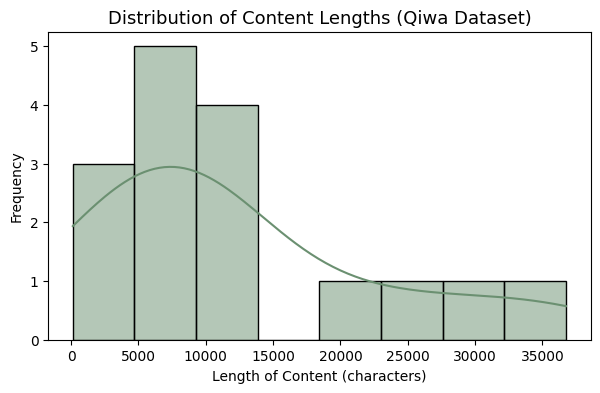

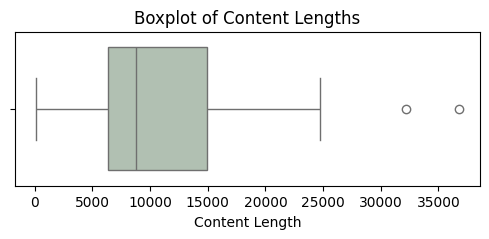

In [ ]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


qiwa_df.columns = (
    qiwa_df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

print(" الأعمدة بعد التنظيف:")
print(qiwa_df.columns.tolist())


if 'content_length' not in qiwa_df.columns:
    text_col = None
    for cand in ['content', 'text', 'body', 'article', 'content_text']:
        if cand in qiwa_df.columns:
            text_col = cand
            break

    if text_col is None:
        raise ValueError(" ما لقيت عمود نص مناسب (content/text/body/article) في qiwa_df.")

    qiwa_df['content_length'] = qiwa_df[text_col].astype(str).str.len()


print(" أول 5 قيم من content_length:")
print(qiwa_df['content_length'].head())

plt.figure(figsize=(7,4))
sns.histplot(qiwa_df["content_length"], bins=8, kde=True, color="#6B9071")
plt.title("Distribution of Content Lengths (Qiwa Dataset)", fontsize=13)
plt.xlabel("Length of Content (characters)")
plt.ylabel("Frequency")
plt.show()


plt.figure(figsize=(6,2))
sns.boxplot(x=qiwa_df["content_length"], color="#AEC3B0")
plt.title("Boxplot of Content Lengths", fontsize=12)
plt.xlabel("Content Length")
plt.show()


 The plots illustrate the distribution of content lengths within the Qiwa dataset. The histogram shows that most texts range between 5,000 and 15,000 characters, with fewer very long entries beyond that. The density curve reveals a right-skewed distribution, meaning there are some exceptionally long documents.
The boxplot further confirms the presence of outliers, representing lengthy legal sections, while the majority of texts fall within the normal mid-range

Top Frequent Words (After Cleaning)

In [ ]:
from collections import Counter
import re
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords', quiet=True)

# Arabic stopwords from NLTK
raw_stops = set(stopwords.words("arabic"))

def normalize_ar(text):
    text = re.sub(r"[ًٌٍَُِّْـ]", "", str(text))
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى", "ي", text)
    text = re.sub(r"ؤ", "و", text)
    text = re.sub(r"ئ", "ي", text)
    text = re.sub(r"[^ء-ي\s]", "", text)
    return text

# Normalize stopwords too (very important)
norm_stops = {normalize_ar(w) for w in raw_stops}

# Add the dataset-specific noise ("الماية" from "المائة")
norm_stops.add("الماية")

tokens = []
for c in qiwa_df["content"].astype(str):
    clean = normalize_ar(c)
    words = clean.split()
    words = [w for w in words if w not in norm_stops and len(w) > 2]
    tokens.extend(words)

freq = Counter(tokens)
top_words = freq.most_common(15)

print("Top meaningful Arabic words:")
for w, c in top_words:
    print(w, ":", c)

Top meaningful Arabic words:
العمل : 1018
المادة : 747
العامل : 358
صاحب : 353
النظام : 177
يجوز : 135
العمال : 122
العقد : 122
عمل : 103
يوما : 99
عقد : 97
اجر : 96
الاجر : 94
والثلاثون : 86
التاسعة : 83


Visualization (Bar Chart)

/tmp/ipython-input-1748638355.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reshaped_words, y=counts, palette="Greens_r")


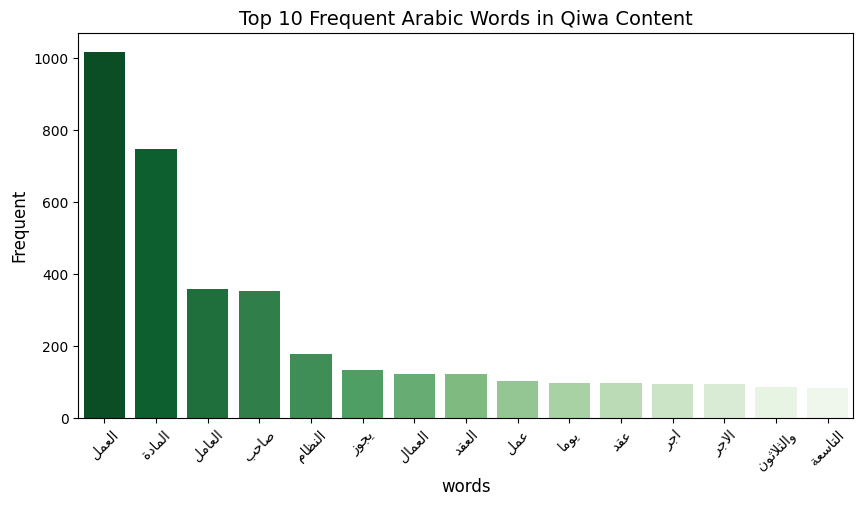

In [ ]:
import arabic_reshaper
from bidi.algorithm import get_display

top_words_fixed = top_words

reshaped_words = [get_display(arabic_reshaper.reshape(w)) for w, c in top_words_fixed]
counts = [c for w, c in top_words_fixed]

plt.figure(figsize=(10,5))
sns.barplot(x=reshaped_words, y=counts, palette="Greens_r")
plt.title("Top 10 Frequent Arabic Words in Qiwa Content", fontsize=14)
plt.xlabel("words", fontsize=12)
plt.ylabel("Frequent", fontsize=12)
plt.xticks(rotation=45)
plt.show()


Word Cloud

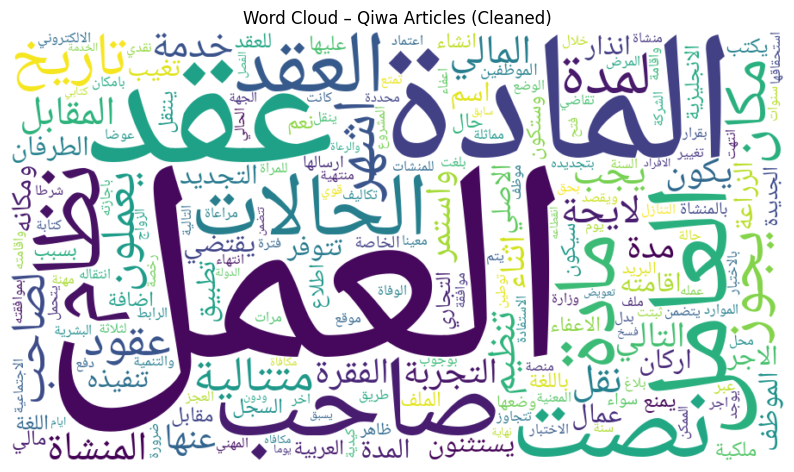

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import arabic_reshaper

# Ensure the Noto Naskh Arabic font is available
!wget -q https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf -O /usr/share/fonts/truetype/NotoNaskhArabic-Regular.ttf
!fc-cache -fv > /dev/null

reshaped_tokens = [arabic_reshaper.reshape(w) for w in tokens]

# نجمعها في نص واحد للـ WordCloud
text_for_wc = " ".join(reshaped_tokens)

wc = WordCloud(
    width=900,
    height=500,
    background_color="white",
    font_path="/usr/share/fonts/truetype/NotoNaskhArabic-Regular.ttf", # Updated font path
    collocations=False
).generate(text_for_wc)

plt.figure(figsize=(10, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – Qiwa Articles (Cleaned)")
plt.show()

##FAQ: Questions & Answers

###Text EDA (Questions Analysis)




Basic Text Stats (Lengths)

In [ ]:

faq_df["Question_length"] = faq_df["Question"].astype(str).apply(len)
faq_df["Answer_length"] = faq_df["Answer"].astype(str).apply(len)

print("Average question length:", round(faq_df["Question_length"].mean(), 2))
print("Average answer length:", round(faq_df["Answer_length"].mean(), 2))

print("\nTop 3 longest questions:")
print(faq_df.sort_values("Question_length", ascending=False).head(3)[["Question"]])


Average question length: 67.5
Average answer length: 178.25

Top 3 longest questions:
                                             Question
13  هل يحق للمؤسسة أو الشركة في حالة تجديد رخصة ال...
5   إذا كان الموظف في فترة التجربة وقرر عدم الاستم...
4   هل يحق للموظف الحصول على مبلغ نقدي كتعويض عن ر...


“The average FAQ question contained 68 characters, while answers averaged 178 characters, showing that responses are much more detailed than inquiries.”

 Distribution of Question Lengths:

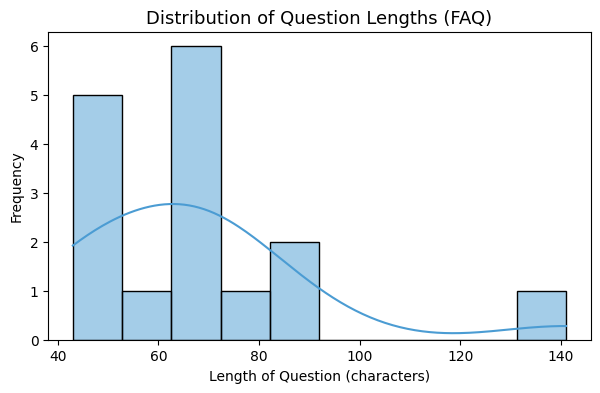

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
sns.histplot(faq_df["Question_length"], bins=10, kde=True, color="#4B9CD3")
plt.title("Distribution of Question Lengths (FAQ)", fontsize=13)
plt.xlabel("Length of Question (characters)")
plt.ylabel("Frequency")
plt.show()


Top Frequent Words :

In [ ]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

# 1) نفس دالة التطبيع اللي نستخدمها في كل المشروع
def normalize_ar(text):
    text = str(text)
    text = re.sub(r'[ًٌٍَُِّْـ]', '', text)        # إزالة التشكيل
    text = re.sub(r'[إأآا]', 'ا', text)           # توحيد الألف
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)  # حذف غير العربي
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 2) نجيب stopwords العربية من NLTK ثم نطبّق عليها normalize
base_sw = stopwords.words('arabic')
base_sw_norm = {normalize_ar(w) for w in base_sw}

# (اختياري) لو حابين نضيف كلمتين عامّة زيادة
extra_sw_raw = {"مثلا", "عندي"}    # مثال فقط، تقدرين تعدلينه
extra_sw_norm = {normalize_ar(w) for w in extra_sw_raw}

arabic_stopwords_q = base_sw_norm | extra_sw_norm
print("عدد stopwords المستخدمة في الأسئلة:", len(arabic_stopwords_q))

# 3) دالة لتقسيم سؤال واحد بعد التنظيف
def tokenize_arabic_clean(text):
    clean = normalize_ar(text)
    words = clean.split()
    words = [w for w in words if len(w) > 2 and w not in arabic_stopwords_q]
    return words

# 4) نطبّقها على عمود الأسئلة
all_words_clean = []
for q in faq_df["Question"].astype(str):
    all_words_clean.extend(tokenize_arabic_clean(q))

# 5) نحسب التكرار
word_freq_clean = Counter(all_words_clean)
top_words_clean = word_freq_clean.most_common(10)

print("\nTop 10 most meaningful words in FAQ questions:")
for w, c in top_words_clean:
    print(f"{w}: {c}")


عدد stopwords المستخدمة في الأسئلة: 625

Top 10 most meaningful words in FAQ questions:
العمل: 7
يجب: 4
عقد: 4
يحق: 4
الموظف: 3
يكون: 2
منشاة: 2
عليها: 2
صاحب: 2
للموظف: 2


The most frequent meaningful words were “العمل”, “يجب”, and “يجوز”, indicating that most FAQ entries focus on labor law obligations, permissions, and employee rights.

Visualization (Top 10 Frequent Words bar chart):

/tmp/ipython-input-3885394586.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reshaped_words, y=counts, palette="Blues_r")
/tmp/ipython-input-3885394586.py:40: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/tmp/ipython-input-3885394586.py:40: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Naskh Arabic.
  fig.canvas.print_figure(bytes_io, **kw)


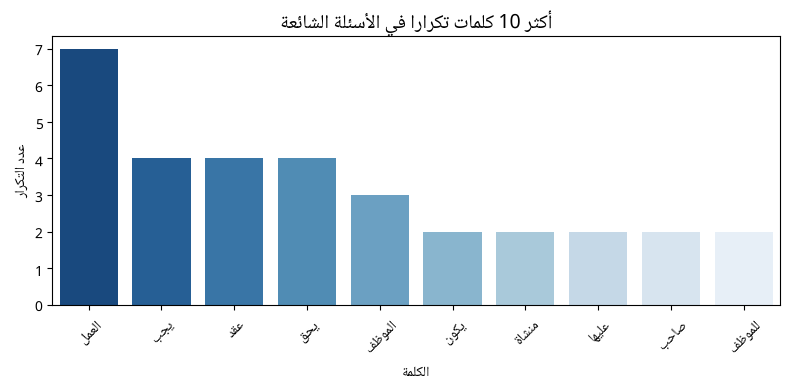

In [ ]:

!pip install arabic-reshaper python-bidi --quiet


!wget -q https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf -O /usr/share/fonts/truetype/NotoNaskhArabic-Regular.ttf


!fc-cache -fv > /dev/null


import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

import arabic_reshaper
from bidi.algorithm import get_display
from wordcloud import WordCloud

# مسار الخط الذي حمّلناه
font_path = "/usr/share/fonts/truetype/NotoNaskhArabic-Regular.ttf"


prop = fm.FontProperties(fname=font_path)

plt.rcParams['font.family'] = prop.get_name()


reshaped_words = [ get_display(arabic_reshaper.reshape(w)) for w, c in top_words_clean ]
counts         = [ c for w, c in top_words_clean ]

plt.figure(figsize=(8, 4))
sns.barplot(x=reshaped_words, y=counts, palette="Blues_r")

plt.title(get_display(arabic_reshaper.reshape("أكثر 10 كلمات تكرارًا في الأسئلة الشائعة")),
          fontproperties=prop, fontsize=14)
plt.xlabel(get_display(arabic_reshaper.reshape("الكلمة")), fontproperties=prop)
plt.ylabel(get_display(arabic_reshaper.reshape("عدد التكرار")), fontproperties=prop)

plt.xticks(rotation=45, fontproperties=prop)
plt.yticks(fontproperties=prop)
plt.tight_layout()
plt.show()


The most frequent words such as “العمل” (work), “يجب” (must), and “يجوز” (allowed) highlight that most FAQs revolve around legal duties and permissions under Saudi labor law. Questions often concern employment contracts and the responsibilities of both employees and employers.

WordCloud:

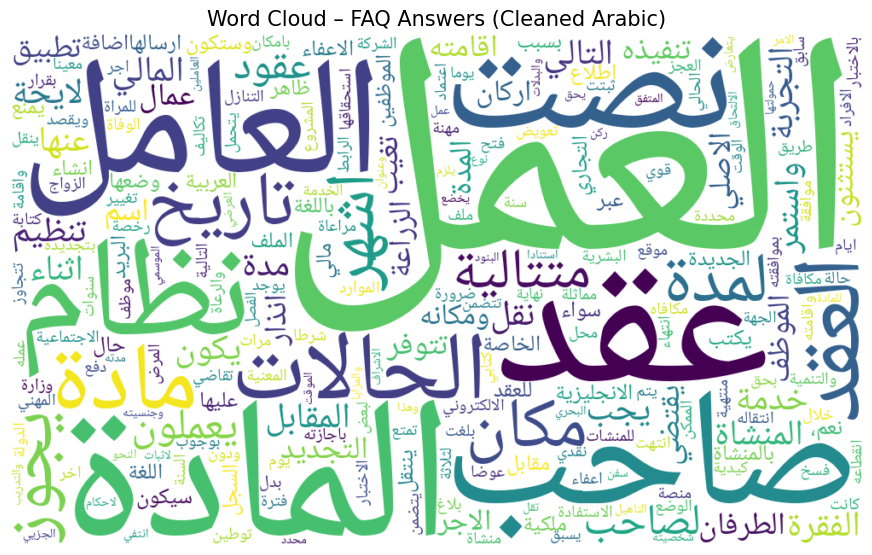

In [ ]:
!apt-get -y install fonts-dejavu-core fonts-dejavu-extra > /dev/null
!wget -q https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf -O /usr/share/fonts/truetype/NotoNaskhArabic-Regular.ttf
!fc-cache -fv > /dev/null

import re
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
import re

def normalize_ar(text):
    text = str(text)
    text = re.sub(r'[ًٌٍَُِّْـ]', '', text)
    # توحيد الألف
    text = re.sub(r'[إأآا]', 'ا', text)
    # توحيد الياء/الألف المقصورة
    text = re.sub(r'ى', 'ي', text)
    # توحيد الهمزات على واو وياء
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    # حذف أي شيء غير حروف عربية أو مسافات
    text = re.sub(r'[^؀-ۿ\s]', ' ', text)
    # دمج المسافات الزايدة
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# دمج القائمتين
all_stops = base_sw_norm | extra_sw_norm

# جمع التوكنز
tokens = []
for ans in faq_df["Answer"].astype(str):
    clean = normalize_ar(ans)
    words = [w for w in clean.split() if len(w) > 2 and w not in all_stops]
    tokens.extend(words)

freq = Counter(tokens)

# رسم WordCloud
wc_answers_clean = WordCloud(
    width=1000, height=600,
    background_color="white",
    font_path="/usr/share/fonts/truetype/NotoNaskhArabic-Regular.ttf", # Corrected font path
    collocations=False,
    max_words=300
).generate_from_frequencies(freq)

plt.figure(figsize=(11,7))
plt.imshow(wc_answers_clean, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – FAQ Answers (Cleaned Arabic)", fontsize=15)
plt.show()

N-gram Analysis Bigrams & Trigram:

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer


def clean_arabic(text):
    text = re.sub(r'[^\u0600-\u06FF\s]', '', str(text))
    return text

faq_clean = faq_df["Question"].apply(clean_arabic)

vectorizer_2 = CountVectorizer(ngram_range=(2,2), analyzer='word')
vectorizer_3 = CountVectorizer(ngram_range=(3,3), analyzer='word')
bigrams = vectorizer_2.fit_transform(faq_clean)
trigrams = vectorizer_3.fit_transform(faq_clean)

bigram_freq = pd.DataFrame({
    'Bigram': vectorizer_2.get_feature_names_out(),
    'Count': bigrams.toarray().sum(axis=0)
}).sort_values('Count', ascending=False).head(10)

trigram_freq = pd.DataFrame({
    'Trigram': vectorizer_3.get_feature_names_out(),
    'Count': trigrams.toarray().sum(axis=0)
}).sort_values('Count', ascending=False).head(10)

print(" Top 10 Bigrams:")
print(bigram_freq)
print("\n Top 10 Trigrams:")
print(trigram_freq)


 Top 10 Bigrams:
          Bigram  Count
136       هل يحق      4
73     عقد العمل      3
154       يجب أن      3
107        ما هي      3
2       أن تتوفر      2
23      التي يجب      2
100  لصاحب العمل      2
70    صاحب العمل      2
54      تتوفر في      2
92        في عقد      2

 Top 10 Trigrams:
             Trigram  Count
1        أن تتوفر في      2
22       التي يجب أن      2
149     يجب أن تتوفر      2
86      في عقد العمل      2
130     هل يحق لصاحب      2
152  يحق لصاحب العمل      2
50      تتوفر في عقد      2
3       أن ينقل موظف      1
0    أخرى دون موافقة      1
9       إلى غير محدد      1


Bigrams (2-word phrases):

“هل يحق” (4×) – most common opener → users ask about legal entitlement.

“عقد العمل” (3×) – contract-related questions are central.

Phrases like “يحق أن”, “ما هي”, “صاحب العمل” (≈2–3×) show clarifying/legal responsibility themes.

Trigrams (3-word phrases):

“هل يحق لصاحب”, “يحق لصاحب العمل” (≈2×) – focus on employer’s rights.

Contextual legal phrasing like “أن تقرر في”, “تقرر في عقد” appears in regulatory explanations.

Interpretation:
FAQ questions are dominated by entitlement/permission language (e.g., is it allowed / is someone entitled?), with a strong concentration on employment contracts and employer–employee responsibilities

##Text EDA (Answers Analysis)

Basic Stats (Answers)

In [ ]:



faq_df["Answer_length"] = faq_df["Answer"].astype(str).apply(len)


print("Average answer length:", round(faq_df["Answer_length"].mean(), 2))
print("Median answer length:", round(faq_df["Answer_length"].median(), 2))


print("\nTop 3 longest answers:")
top3_answers = faq_df.sort_values("Answer_length", ascending=False).head(3)
for i, row in enumerate(top3_answers["Answer"], 1):
    print(f"\n{i}.", str(row)[:200], "...")


Average answer length: 178.25
Median answer length: 173.0

Top 3 longest answers:

1. أثناء التجربة حسب ما نصت عليه المادة 53 الحالات حسب ما نصت عليه المادة 74 الحالات حسب ما نصت عليه المادة 80 الحالات حسب ما نصت عليه المادة 81 للمرأة 6 أشهر من الزواج أو 3 أشهر من الوضع مادة 87 المرض م ...

2. نعـم على صاحب العمل إطلاع الموظفين على لائحة تنظيم العمل الخاصة بالمنشأة سواء وضعها في مكان ظاهـر أو إرسالها عبر البريد الإلكتروني أو عـن طريـق موقـع الشـركة كما بإمكان صاحب العمل الاستفادة من خدمة اع ...

3. عقود العمل التي لا تتضمن مكافأة نهاية الخدمة هي: عقد العمل لبعض الوقت (الجزئي ) عقد العمل المؤقت عقد العمل الموسمي عقد العمل العرضي عقود العمل البحري الذين يعملون في سفن تقل حمولتها عن 500 طن عقود الت ...


Average answer length: 178.25 characters
→ Most answers are short and concise, focusing on explaining a single rule or case.

Median answer length: 173 characters
→ The similarity between average and median indicates consistent answer lengths, with no major outliers.

Top 3 longest answers:
These belong to more detailed legal topics — such as probation periods, reporting obligations, and special contract types — which naturally require longer explanations.

💡 Interpretation:
FAQ answers are generally brief and standardized, written to provide quick, clear responses. Only a few, like legal clarifications, are longer because they include article numbers or procedural steps

Histogram of Answer Lengths

In [ ]:
import pandas as pd

# لو كنتِ أصلاً حاسبة الطول مسبقًا ok، لكن نتأكد إنه رقمي:
faq_df["Answer_length"] = pd.to_numeric(faq_df["Answer_length"], errors="coerce")

# نشيل القيم الفارغة
answer_lengths = faq_df["Answer_length"].dropna()


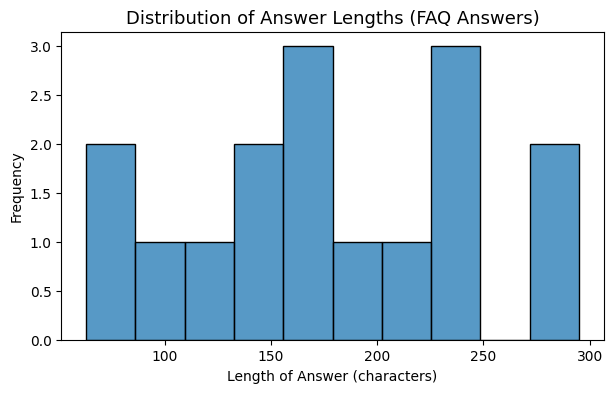

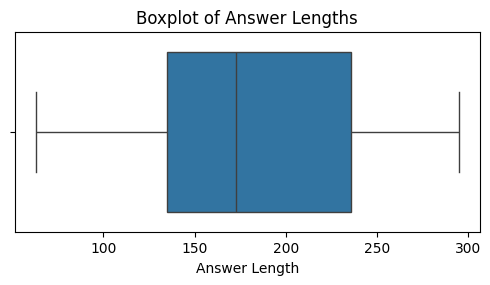

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


# Histogram بدون KDE (أهدى وأقل وارننق)
plt.figure(figsize=(7, 4))
sns.histplot(answer_lengths, bins=10)
plt.title("Distribution of Answer Lengths (FAQ Answers)", fontsize=13)
plt.xlabel("Length of Answer (characters)")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(6, 2.6))
sns.boxplot(x=answer_lengths)
plt.title("Boxplot of Answer Lengths", fontsize=12)
plt.xlabel("Answer Length")
plt.show()


The histogram shows that most answers fall between 120–250 characters, with no major outliers.
This indicates that the responses are consistent in length — most answers are concise and standardized.
The boxplot supports this: there are no extreme values, meaning the answers maintain a uniform format.

Histogram of Answer Lengths

In [ ]:
from collections import Counter
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

# Re-defining normalize_ar to ensure it's available in this scope
def normalize_ar(text):
    text = str(text)
    text = re.sub(r'[ًٌٍَُِّْـ]', '', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    text = re.sub(r'[^؀-ۿ\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Define the stopwords set correctly
base_sw = set(stopwords.words('arabic'))
base_sw_norm = {normalize_ar(w) for w in base_sw}
extra_sw_raw = {"المائة", "الماية"}
extra_sw_norm = {normalize_ar(w) for w in extra_sw_raw}
stopwords_set = base_sw_norm | extra_sw_norm

tokens = []
for a in faq_df["Answer"].astype(str):
    clean = normalize_ar(a)
    words = [w for w in clean.split() if len(w) > 2 and w not in stopwords_set]
    tokens.extend(words)

freq = Counter(tokens)
top_clean = freq.most_common(10)

print("Top 10 Frequent Words in Answers (After Cleaning):")
for w, c in top_clean:
    print(f"{w}: {c}")

Top 10 Frequent Words in Answers (After Cleaning):
العمل: 28
المادة: 8
عقد: 8
صاحب: 7
العامل: 7
نصت: 6
نظام: 5
الحالات: 4
مادة: 4
العقد: 4


Visualization of Most Frequent Words in Answers

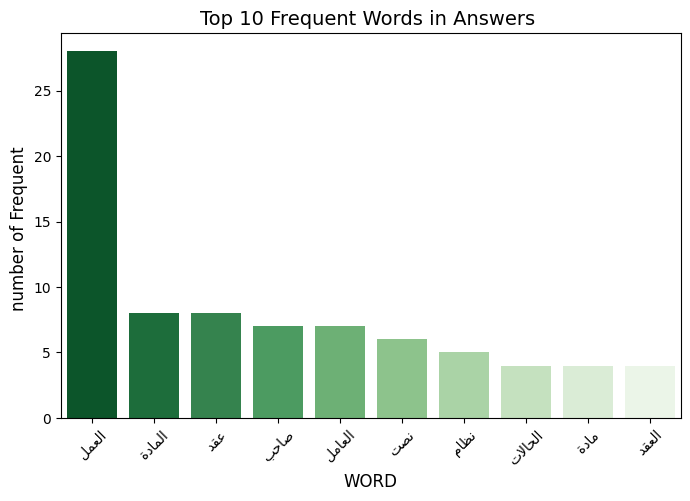

In [ ]:
!pip install arabic-reshaper python-bidi > /dev/null

import arabic_reshaper
from bidi.algorithm import get_display
import warnings
warnings.filterwarnings("ignore")


reshaped_words = [get_display(arabic_reshaper.reshape(w)) for w, _ in top_clean]
counts = [c for _, c in top_clean]

plt.figure(figsize=(8,5))
sns.barplot(x=reshaped_words, y=counts, palette='Greens_r')
plt.title("Top 10 Frequent Words in Answers ", fontsize=14)
plt.xlabel("WORD", fontsize=12)
plt.ylabel("number of Frequent ", fontsize=12)
plt.xticks(rotation=45)
plt.show()


Word Cloud for Answers

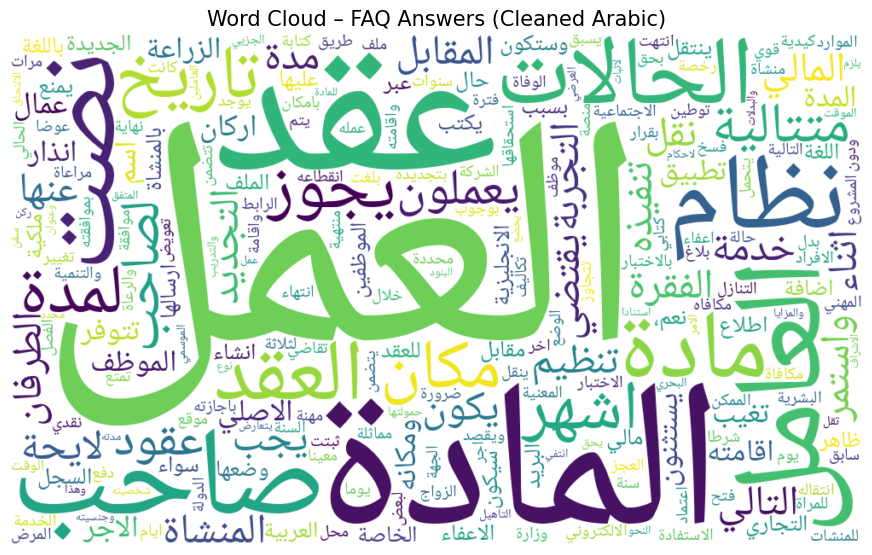

In [ ]:
!apt-get -y install fonts-dejavu-core fonts-dejavu-extra > /dev/null
!wget -q https://github.com/googlefonts/noto-fonts/raw/main/hinted/ttf/NotoNaskhArabic/NotoNaskhArabic-Regular.ttf -O /usr/share/fonts/truetype/noto.ttf

import re
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import warnings
warnings.filterwarnings("ignore")

nltk.download('stopwords', quiet=True)
import re

def normalize_ar(text):
    text = str(text)
    text = re.sub(r'[ًٌٍَُِّْـ]', '', text)
    # توحيد الألف
    text = re.sub(r'[إأآا]', 'ا', text)
    # توحيد الياء/الألف المقصورة
    text = re.sub(r'ى', 'ي', text)
    # توحيد الهمزات على واو وياء
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    # حذف أي شيء غير حروف عربية أو مسافات
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    # دمج المسافات الزايدة
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# دمج القائمتين
all_stops = base_sw_norm | extra_sw_norm

# جمع التوكنز
tokens = []
for ans in faq_df["Answer"].astype(str):
    clean = normalize_ar(ans)
    words = [w for w in clean.split() if len(w) > 2 and w not in all_stops]
    tokens.extend(words)

freq = Counter(tokens)

# رسم WordCloud
wc_answers_clean = WordCloud(
    width=1000, height=600,
    background_color="white",
    font_path="/usr/share/fonts/truetype/noto.ttf",
    collocations=False,
    max_words=300
).generate_from_frequencies(freq)

plt.figure(figsize=(11,7))
plt.imshow(wc_answers_clean, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud – FAQ Answers (Cleaned Arabic)", fontsize=15)
plt.show()


relationship between the length of the questions and the length of the answers:

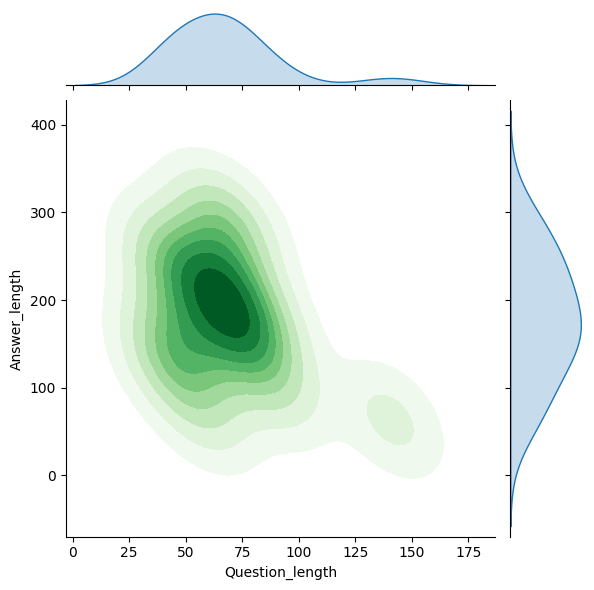

In [ ]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans'  # الخط الافتراضي


sns.jointplot(
    data=faq_df,
    x="Question_length",
    y="Answer_length",
    kind="kde",   # توزيع ناعم، مرررة شكله راقي
    fill=True,
    cmap="Greens"
)


This plot shows the relationship between the length of the questions and the length of the answers in the Labor Law FAQ dataset.

The density map indicates that most questions fall within the range of 50–90 characters, while most answers fall within 150–250 characters.

There is no strong linear relationship between the two variables; answers can still be long even when the question is short.

The side distributions clearly show that the spread of answer lengths is much wider than that of the questions, reflecting the nature of the dataset—short, simple questions and long, detailed answers.

TF-IDF Analysis (Questions vs Answers)




In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)

# Correctly get the stopwords as a set of words
arabic_stopwords = set(stopwords.words('arabic'))

tokens = []
for c in qiwa_df["content"].astype(str):
    clean = normalize_ar(c)
    # Use the correctly loaded stopwords set
    words = [w for w in clean.split() if len(w) > 2 and w not in arabic_stopwords]
    tokens.extend(words)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import re
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

def normalize_ar(text):
    text = str(text)
    text = re.sub(r'[ًٌٍَُِّْـ]', '', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 1) stopwords من NLTK
base_sw = set(stopwords.words("arabic"))
base_sw_norm = {normalize_ar(w) for w in base_sw}

# 2) كلمات إضافية خاصّة بالبيانات (اختياري)
extra_sw_raw = {
    "المائة", "الماية",      # ترقيم مواد / artifact
    "على", "الى", "إلى",     # عشان ما تطلع علي / الي بعد normalize
}
extra_sw_norm = {normalize_ar(w) for w in extra_sw_raw}

all_stops = base_sw_norm | extra_sw_norm

# 3) دالة تنظيف النص (تستخدم المكتبة مو لستة يدويّة)
def clean_text(t):
    t = normalize_ar(t)
    return " ".join(
        w for w in t.split()
        if len(w) > 2 and w not in all_stops
    )

# 4) تجهيز نصوص الأسئلة والأجوبة
Q_texts = [clean_text(q) for q in faq_df["Question"].astype(str)]
A_texts = [clean_text(a) for a in faq_df["Answer"].astype(str)]

texts = Q_texts + A_texts
labels = np.array(["Q"]*len(Q_texts) + ["A"]*len(A_texts))

# 5) TF-IDF على 1-gram و 2-gram
vec = TfidfVectorizer(ngram_range=(1,2), max_features=3000)
X = vec.fit_transform(texts)
terms = vec.get_feature_names_out()

# 6) متوسط الـ TF-IDF لكل مصطلح في الأسئلة مقابل الأجوبة
Q_mean = X[labels=="Q"].mean(axis=0).A1
A_mean = X[labels=="A"].mean(axis=0).A1
delta = A_mean - Q_mean   # موجب = مميّز أكثر في الأجوبة، سالب = في الأسئلة

# أعلى 10 مميّزة للأجوبة
top_A = np.argsort(delta)[-10:][::-1]
# أعلى 10 مميّزة للأسئلة (أكثر سالبية)
top_Q = np.argsort(delta)[:10]

print("=== Distinctive for ANSWERS ===")
for i in top_A:
    print(terms[i], round(delta[i], 4))

print("\n=== Distinctive for QUESTIONS ===")
for i in top_Q:
    print(terms[i], round(delta[i], 4))


=== Distinctive for ANSWERS ===
المادة 0.057
العامل 0.0404
نصت 0.0393
العمل 0.0344
نظام 0.028
نظام العمل 0.028
تاريخ 0.0252
المادة نظام 0.0242
نصت المادة 0.0242
الحالات 0.024

=== Distinctive for QUESTIONS ===
يجب -0.0443
يجب تتوفر -0.0384
تتوفر عقد -0.0357
المستثنون -0.035
عليها -0.0313
يحق -0.0306
يمكن -0.0298
البنود يجب -0.0277
للموظف -0.0276
تتوفر -0.0272


The TF-IDF analysis clearly shows a distinction between the nature of questions and answers:

Answers are dominated by legal terms such as “article,” “stated,” “labor law,” reflecting direct quotations from official legal texts.

Questions, on the other hand, include words like “is it allowed,” “must,” “available,” “documents,” “employee,” indicating a human, inquiry-based tone.

 Conclusion:
Questions tend to be inquisitive and user-oriented, while answers are formal and law-driven, confirming that the dataset is well-suited for developing a legal Q&A model or for use in LLM fine-tuning.

### Secondary Dataset — Labor Law FAQ

##  EDA Summary
This dataset contains common questions and answers about labor law.
Question and answer lengths were analyzed, and frequent Arabic terms were extracted to identify popular topics.
Visualizations included histograms, bar charts, and a word cloud to show common terms.
Optional TF-IDF analysis highlighted distinctive words between questions and answers.


## Metadata Review
The dataset was collected from the **FAQ section** on the official **Qiwa.sa** website,
representing public inquiries about the Saudi Labor Law.


##  Bias Awareness
The questions reflect user curiosity and confusion rather than the full scope of the law,
so the data may emphasize topics the public struggles with most.



## Length Analysis: Full Legal Text vs User Queries

In [ ]:
faq_df["question_length"] = faq_df["Question"].astype(str).str.len()


print("Avg Qiwa article length:", qiwa_df["content_length"].mean())
print("Avg FAQ question length:", faq_df["question_length"].mean())

Avg Qiwa article length: 12262.5
Avg FAQ question length: 67.5


The average Qiwa article contains about 12,262 characters, while the average user question contains only 67 characters. This means that users interact with only 0.55% of the original legal content. This highlights a major gap between what the law contains and what users actually ask about, and demonstrates the importance of simplifying legal texts into short Q&A formats.

##Comparison: Basic metrics (FAQ vs Qiwa)

In [ ]:

import pandas as pd
import numpy as np
import re
from collections import Counter

import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

def normalize_ar(text):
    text = str(text)
    text = re.sub(r'[ًٌٍَُِّْـ]', '', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# stopwords العربية من المكتبة
base_sw = set(stopwords.words("arabic"))
# نطبّق عليها normalize حتى تتطابق مع النص المنظَّف
base_sw_norm = {normalize_ar(w) for w in base_sw}

extra_sw_raw = {
    "الماية", "المائة",    # خطأ ناتج عن التنقية
    "على", "الى", "إلى",   # لتفادي ظهور "علي" و "الي"
    "اذا", "إذا"
}
extra_sw_norm = {normalize_ar(w) for w in extra_sw_raw}

stopwords_set = base_sw_norm | extra_sw_norm
print("Total stopwords used:", len(stopwords_set))

# ========== 4) دالة tokenization + تنظيف Series كامل ==========
def tokenize_clean(series: pd.Series):
    tokens = []
    for s in series.astype(str):
        s_norm = normalize_ar(s)
        words = [
            w for w in s_norm.split()
            if len(w) > 2 and w not in stopwords_set
        ]
        tokens.extend(words)
    return tokens

# ========== 5) دالة ذكية لاختيار/حساب طول محتوى Qiwa ==========
def ensure_content_length(df: pd.DataFrame) -> pd.Series:
    """
    ترجع Series تمثّل طول المحتوى لكل صف في df (عدد الحروف)
    تحاول أولاً استخدام أعمدة جاهزة إن وجدت، ثم تبحث عن أنسب عمود نصّي.
    """

    # 5.1 لو فيه عمود جاهز لطول النص نستعمله
    for cand in ['Content_length', 'content_length', 'Content_len', 'content_len']:
        if cand in df.columns:
            s = pd.to_numeric(df[cand], errors='coerce')
            if s.isna().mean() < 0.9:   # مو كلّها NaN
                return s.fillna(0)

    # 5.2 نحاول إيجاد عمود نصّي واضح للمحتوى
    for text_col in ['Content', 'content', 'Text', 'text',
                     'ArticleText', 'Article', 'المحتوى', 'النص']:
        if text_col in df.columns:
            return df[text_col].astype(str).str.len()

    # 5.3 لو ما عرفنا، نختار أطول عمود نصّي كمتوسط طول
    obj_cols = [c for c in df.columns if df[c].dtype == 'object']
    if obj_cols:
        lens = {c: df[c].astype(str).str.len().mean() for c in obj_cols}
        best = max(lens, key=lens.get)
        print(f"[info] Using '{best}' as content column (auto-picked).")
        return df[best].astype(str).str.len()

    # 5.4 fallback لو ما فيه نصوص
    return pd.Series([0]*len(df), index=df.index)

# ========== 6) حساب أطوال FAQ (سؤال + جواب) ==========
faq_q_len   = faq_df["Question"].astype(str).apply(len)
faq_a_len   = faq_df["Answer"].astype(str).apply(len)
faq_all_len = pd.concat([faq_q_len, faq_a_len], ignore_index=True)

# ========== 7) حساب أطوال مقالات قوى ==========
qiwa_len = ensure_content_length(qiwa_df)

# ========== 8) بناء جدول المقارنة ==========
metrics = pd.DataFrame({
    "dataset": ["FAQ (Q + A)", "Qiwa (Articles)"],
    "rows":    [len(faq_df)*2, len(qiwa_df)],
    "avg_len": [round(faq_all_len.mean(), 2), round(qiwa_len.mean(), 2)],
    "median":  [round(faq_all_len.median(), 2), round(qiwa_len.median(), 2)]
})

metrics


Total stopwords used: 624


,dataset,rows,avg_len,median
0,FAQ (Q + A),32,122.88,87.0
1,Qiwa (Articles),16,12262.50,8771.5


In [ ]:
import pandas as pd
import re
from collections import Counter
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords", quiet=True)

def normalize_ar(text):
    text = str(text)
    text = re.sub(r'[ًٌٍَُِّْـ]', '', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'[ى]', 'ي', text)
    text = re.sub(r'[ؤ]', 'و', text)
    text = re.sub(r'[ئ]', 'ي', text)
    text = re.sub(r'[^\u0600-\u06FF\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# stopwords من مكتبة NLTK (جاهزة ومعتمدة علمياً)
nltk_sw = set(stopwords.words("arabic"))
nltk_sw_norm = {normalize_ar(w) for w in nltk_sw}

# كلمات خاصة بالداتا فقط (Artifacts)
domain_raw = {"المايتين", "يوما", "والثلاثون"}
domain_norm = {normalize_ar(w) for w in domain_raw}

# القائمة النهائية (مكتبية + domain)
stopwords_set = nltk_sw_norm | domain_norm

def tokenize_clean(series):
    toks = []
    for s in series.astype(str):
        s = normalize_ar(s)
        toks += [w for w in s.split() if len(w) > 2 and w not in stopwords_set]
    return toks

def pick_text_col(df):
    candidates = ['Content','content','Text','text','ArticleText','Article','Body','body','المحتوى','النص']
    for c in candidates:
        if c in df.columns:
            return df[c].astype(str)
    obj_cols = [c for c in df.columns if df[c].dtype=='object']
    if obj_cols:
        avg_lens = {c: df[c].astype(str).str.len().mean() for c in obj_cols}
        best = max(avg_lens, key=lens.get)
        return df[best].astype(str)
    return pd.Series(['']*len(df), index=df.index)

faq_text = pd.concat([faq_df["Question"], faq_df["Answer"]], ignore_index=True).astype(str)
qiwa_text = pick_text_col(qiwa_df)

faq_tokens = tokenize_clean(faq_text)
qiwa_tokens = tokenize_clean(qiwa_text)

vocab_faq = set(faq_tokens)
vocab_qiwa = set(qiwa_tokens)

jaccard = len(vocab_faq & vocab_qiwa) / max(1, len(vocab_faq | vocab_qiwa))
print(f"Jaccard overlap: {jaccard:.3f}")

faq_top  = Counter(faq_tokens).most_common(15)
qiwa_top = Counter(qiwa_tokens).most_common(15)

print("\nTop 15 — FAQ:")
for w,c in faq_top: print(w,c)

print("\nTop 15 — Qiwa:")
for w,c in qiwa_top: print(w,c)

faq_unique  = [w for w,_ in faq_top  if w not in vocab_qiwa]
qiwa_unique = [w for w,_ in qiwa_top if w not in vocab_faq]

print("\nUnique FAQ:", ", ".join(faq_unique[:8]))
print("Unique Qiwa:", ", ".join(qiwa_unique[:8]))


Jaccard overlap: 0.058

Top 15 — FAQ:
العمل 35
عقد 12
صاحب 9
العامل 8
المادة 8
يجب 6
العقد 6
نظام 6
نصت 6
الموظف 5
يحق 5
مادة 5
لصاحب 5
مكان 5
يكون 4

Top 15 — Qiwa:
العمل 946
المادة 738
صاحب 353
العامل 350
الماية 318
النظام 140
يجوز 135
العقد 113
العمال 112
عمل 98
عقد 97
الاجر 92
اجر 91
التاسعة 83
الخامسة 82

Unique FAQ: الموظف
Unique Qiwa: الماية, النظام, التاسعة, الخامسة


Final Comparative Analysi

In [ ]:
import pandas as pd, numpy as np, re
from collections import Counter

try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    def fix_ar(s):
        try: return get_display(arabic_reshaper.reshape(str(s)))
        except: return s
except:
    def fix_ar(s): return s

def ensure_df(var_name, fallback_csv):
    g = globals()
    if var_name in g and isinstance(g[var_name], pd.DataFrame):
        return g[var_name]
    try:
        df = pd.read_csv(fallback_csv, encoding="utf-8-sig")
        globals()[var_name] = df
        return df
    except Exception as e:
        raise RuntimeError(f"لم أجد المتغير `{var_name}` ولا الملف `{fallback_csv}`. عدّلي الاسم أو حمّلي الملف. Original: {e}")

boe      = ensure_df("boe",      "boe_cleaned.csv")
istitlaa = ensure_df("istitlaa", "istitlaa_cleaned.csv")
faq      = ensure_df("faq_df",   "labor_law_faq_cleaned.csv")


def get_article_num(text):
    if not isinstance(text, str):
        return np.nan
    m = re.search(r'\d+', text)
    if m:
        return int(m.group())
    words = {
        "الثانية":2,"الثالثة":3,"الرابعة":4,"الخامسة":5,"السادسة":6,"السابعة":7,"الثامنة":8,"التاسعة":9,
        "العاشرة":10,"الحادية عشرة":11,"الثانية عشرة":12,"الثالثة عشرة":13,"الرابعة عشرة":14,"الخامسة عشرة":15,
        "السادسة عشرة":16,"السابعة عشرة":17,"الثامنة عشرة":18,"التاسعة عشرة":19,"العشرون":20
    }
    for w,n in words.items():
        if w in text:
            return n
    return np.nan


if 'Article_num' not in boe.columns:
    boe['Article_num'] = boe['Article'].apply(get_article_num)
if 'Article_num' not in istitlaa.columns:
    istitlaa['Article_num'] = istitlaa['Article'].apply(get_article_num)


status_col = 'Status' if 'Status' in boe.columns else 'status'
boe_mod = boe.loc[boe[status_col].astype(str).str.contains("معدل|معدلة|معدّلة", regex=True), ['Article_num','Text','Section','Chapter']]
boe_mod = boe_mod.dropna(subset=['Article_num']).drop_duplicates(subset=['Article_num'])


istit = istitlaa[['Article_num','Current Text','Proposed Text','URL']].dropna(subset=['Article_num']).drop_duplicates(subset=['Article_num'])


boe_istit_merge = (boe_mod.merge(istit, on='Article_num', how='inner')
                        .sort_values('Article_num')
                  )

print("=== BOE ↔ Istitlaa (مواد مشتركة بحسب رقم المادة) ===")
print(f"عدد المواد المعدّلة في BOE: {boe_mod['Article_num'].nunique()}")
print(f"عدد مواد استطلاع:         {istit['Article_num'].nunique()}")
print(f"عدد المواد المشتركة:       {boe_istit_merge['Article_num'].nunique()}\n")
display(boe_istit_merge.head(10))



arabic_punct = r"[^\u0600-\u06FF\s]"
stopwords = set("""من إلى عن على في فيه فيها عليه عليها لديهم لديهم لدى هذا هذه ذلك تلك التي الذي الذين اللواتي هن هو هي هم هنك لكم لكم لنا كنت كان تكون تكونوا تكونين تكونان تكونون يكون تكون كنت كانوا كانت كنّ""".split())

def normalize_ar(s):
    s = re.sub(arabic_punct, " ", str(s))
    s = re.sub(r"\s+", " ", s).strip()

    s = s.replace("أ","ا").replace("إ","ا").replace("آ","ا").replace("ى","ي").replace("ؤ","و").replace("ئ","ي").replace("ة","ه")
    return s

def tokenize_clean(s):
    toks = normalize_ar(s).split()
    return [t for t in toks if len(t) > 2 and t not in stopwords]


boe_text_all = " ".join(boe_mod['Text'].astype(str).tolist())
boe_tokens   = tokenize_clean(boe_text_all)


faq_text_all = " ".join((faq.get('Question','').astype(str) + " " + faq.get('Answer','').astype(str)).tolist())
faq_tokens   = tokenize_clean(faq_text_all)


boe_freq = Counter(boe_tokens)
faq_freq = Counter(faq_tokens)


common_vocab = set(boe_freq) & set(faq_freq)
jaccard = len(common_vocab) / (len(set(boe_freq)|set(faq_freq)) + 1e-9)

boe_top = boe_freq.most_common(15)
faq_top = faq_freq.most_common(15)

print("\n=== BOE ↔ Qiwa (FAQ) — تشابه مفردات عام ===")
print(f"حجم مفردات BOE: {len(boe_freq):,} | حجم مفردات Qiwa: {len(faq_freq):,}")
print(f"تشابه Jaccard:  {jaccard:.3f}\n")

print("Top 10 in BOE:")
for w,c in boe_top[:10]:
    print(f"{w}: {c}")
print("\nTop 10 in Qiwa:")
for w,c in faq_top[:10]:
    print(f"{w}: {c}")

def distinctive(topk=15):

    scores_boe = [(w, boe_freq[w]/(faq_freq[w]+1)) for w in boe_freq]
    scores_faq = [(w, faq_freq[w]/(boe_freq[w]+1)) for w in faq_freq]
    top_boe = sorted(scores_boe, key=lambda x: x[1], reverse=True)[:topk]
    top_faq = sorted(scores_faq, key=lambda x: x[1], reverse=True)[:topk]
    return top_boe, top_faq

top_boe_dist, top_faq_dist = distinctive(12)
print("\n=== كلمات مميزة أكثر في BOE ===")
for w,s in top_boe_dist:
    print(f"{w}")

print("\n=== كلمات مميزة أكثر في Qiwa ===")
for w,s in top_faq_dist:
    print(f"{w}")


=== BOE ↔ Istitlaa (مواد مشتركة بحسب رقم المادة) ===
عدد المواد المعدّلة في BOE: 11
عدد مواد استطلاع:         13
عدد المواد المشتركة:       3



,Article_num,Text,Section,Chapter,Current Text,Proposed Text,URL
0,2.0,- تعديل تعريف العامل وذلك بموجب المرسوم الملكي...,الباب الأول التعريفات والأحكام العامة,الفصل الأول التعريفات,المادة (2) في تنفيذ أحكام الفقرة الفرعية (د) م...,حذف المادة ​,https//istitlaa.ncc.gov.sa/ar/labor/hrsd/regul...
1,7.0,تم تعديل هذه المادة بموجب المرسوم الملكي رقم (...,الباب الأول التعريفات والأحكام العامة,الفصل الأول التعريفات,المادة (7) في تنفيذ أحكام المواد (الثانية والع...,المادة (7) في تنفيذ أحكام المواد (الثانية والع...,https//istitlaa.ncc.gov.sa/ar/labor/hrsd/regul...
2,10.0,تم إلغاء الباب الرابع عشر بموجب المرسوم الملكي...,الباب الرابع عشر هيئات تسوية الخلافات العمالية,الفصل الأول التعريفات,المادة (10) في تنفيذ أحكام (المادة الثلاثون) م...,المادة (10) في تنفيذ أحكام (المادة الثلاثون) م...,https//istitlaa.ncc.gov.sa/ar/labor/hrsd/regul...



=== BOE ↔ Qiwa (FAQ) — تشابه مفردات عام ===
حجم مفردات BOE: 360 | حجم مفردات Qiwa: 325
تشابه Jaccard:  0.101

Top 10 in BOE:
العمل: 24
علي: 15
الماده: 12
المرسوم: 11
الملكي: 11
وتاريخ: 11
صاحب: 11
الاتي: 10
بموجب: 9
رقم: 9

Top 10 in Qiwa:
العمل: 35
عقد: 12
علي: 11
صاحب: 9
الماده: 8
العامل: 8
اذا: 8
يجب: 6
نصت: 6
نظام: 6

=== كلمات مميزة أكثر في BOE ===
المرسوم
الملكي
وتاريخ
الاتي
بموجب
رقم
تعديل
بالنص
لتكون
يعمل
عشره
هـ،

=== كلمات مميزة أكثر في Qiwa ===
نصت
الموظف
يحق
ماده
عقد
العامل
حسب
الحالات
المده
تتوفر
المقابل
المالي
